## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each LAU1 Unit ##

In [1]:
import pandas as pd
import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../../Modules")

from utils import *

enc = 'utf-8'
dec = 'greek8'

random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [5]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [6]:
#choose the correct region

nuts2_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΘΕΣΣΑΛΙΑΣ']
nuts2_gdf.head()

,PER,geometry
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [7]:
indexes = []

nuts2 = nuts2_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [8]:
nuts2_gdf.head()

,NAME,KWD_YPES,geometry
0,Αγιάς,9097,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
1,Αγράφων,9156,"POLYGON ((21.64628 39.24473, 21.64720 39.24471..."
2,Αλοννήσου,9109,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
3,Αλμυρού,9104,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
4,Αμφιλοχίας,9125,"MULTIPOLYGON (((21.15577 38.98239, 21.15567 38..."


<AxesSubplot:>

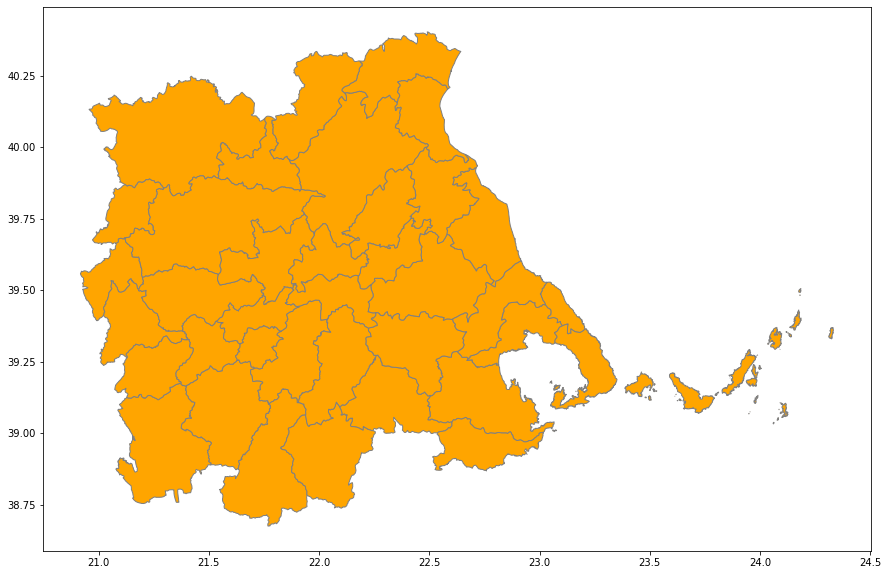

In [9]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [10]:
#check QGIS for wrong lau1 units

In [11]:
wrong_list = ['Δίου - Ολύμπου' ,'Κατερίνης', 'Σερβίων - Βελβεντού', 'Δεσκάτης', 'Γρεβενών', 'Μετσόβου', 'Βορείων Τζουμέρκων', 'Κεντρικών Τζουμέρκων',
 'Γεωργίου Καραϊσκάκη', 'Αμφιλοχίας', 'Αγράφων', 'Καρπενησίου', 'Μακρακώμης', 'Δομοκού', 'Στυλίδας']

nuts2_gdf = nuts2_gdf[~nuts2_gdf['NAME'].isin(wrong_list)].copy()

In [12]:
nuts2_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αγιάς,9097,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
2,Αλοννήσου,9109,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
3,Αλμυρού,9104,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
5,Αργιθέας,9091,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
6,Βόλου,9105,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


In [13]:
nuts2_gdf.drop(columns=['KWD_YPES'], inplace = True)
nuts2_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(nuts2_gdf, 'lau1')

In [14]:
nuts2_gdf.head(5)

,lau1,geometry
0,αγιας,"MULTIPOLYGON (((22.89063 39.67169, 22.89056 39..."
2,αλοννησου,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39..."
3,αλμυρου,"MULTIPOLYGON (((23.06753 39.00526, 23.06740 39..."
5,αργιθεας,"POLYGON ((21.43616 39.41522, 21.43830 39.41454..."
6,βολου,"POLYGON ((22.97208 39.45655, 22.97346 39.45643..."


<AxesSubplot:>

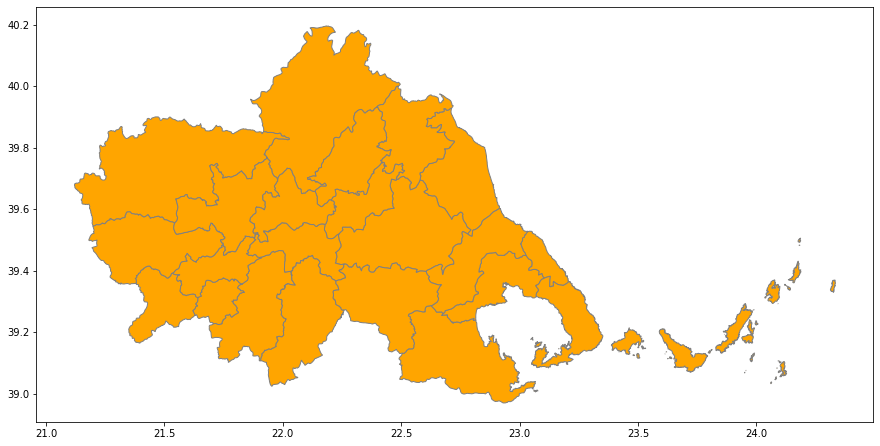

In [15]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [16]:
indexes = []

nuts2 = nuts2_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [17]:
nuts2_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,3,GR0004000400260520N,ÔÁÕÑÙÐÏÓ Ð.,TAVROPOS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,42710.979405,"LINESTRING (21.76727 39.18674, 21.76728 39.186..."
1,5,GR0008000400220360N,ÅÍÉÐÅÕÓ Ð.,ENIPEYS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,13274.085824,"LINESTRING (22.11585 39.49631, 22.11806 39.495..."
2,5,GR0008000400220360N,ÅÍÉÐÅÕÓ Ð.,ENIPEYS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,13274.085824,"LINESTRING (22.11585 39.49631, 22.11806 39.495..."
3,31,GR0008000400220550N,ÊÁÑÁÌÐÁËÇÓ Ð.,KARABALIS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4406.675683,"LINESTRING (21.93452 39.34592, 21.93566 39.346..."
4,34,GR0008000400220580N,ÐÇÍÅÉÏÓ Ð.,PINIOS R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4406.675683,"LINESTRING (22.02974 39.55998, 22.03116 39.561..."


<AxesSubplot:>

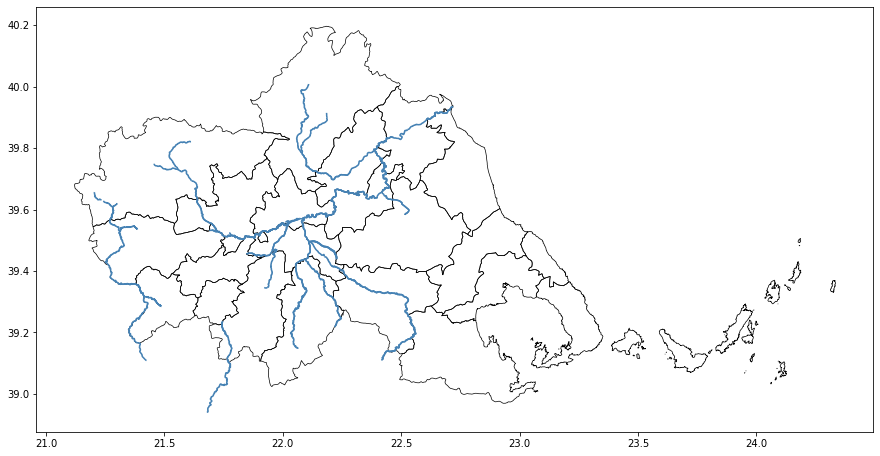

In [18]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [19]:
lau1_units = nuts2_gdf['lau1'].unique().tolist()

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_LAU1_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in lau1_units:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in {NUTS2} (from shapefile): {len(lau1_units)}")

Number of LAU1 Units in Thessaly (from shapefile): 25


In [20]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [75]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='lau1', dimension=3.5)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

e:\Drive\NOA\MBD-Prediction\Greece\notebooks\Thessaly\../../../Modules\utils.py:671: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shape

In [76]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

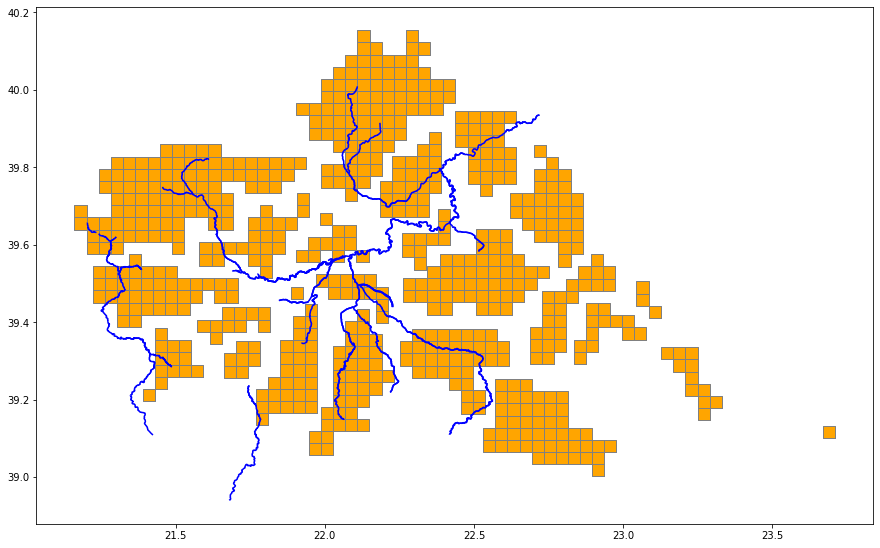

In [77]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [78]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 23


['αλοννησου', 'σκιαθου']


C:\Users\dimit\AppData\Local\Temp/ipykernel_7224/839959091.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lost_lau1["centroid"] = lost_lau1["geometry"].centroid
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


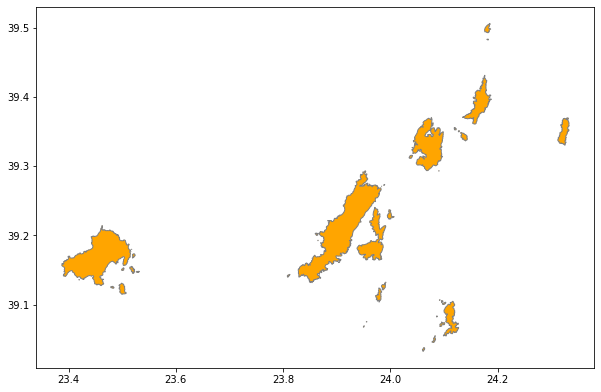

In [79]:
if (len(lau1_units) != len(grid_lau1)):
    delta = [item for item in lau1_units if item not in grid_lau1]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['lau1'] = lost_lau1['lau1']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [80]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [81]:
nuts2_grid

,geometry,lau1,x,y
0,"POLYGON ((22.66044 39.66926, 22.66044 39.70070...",αγιας,22.64007,39.68498
1,"POLYGON ((22.66044 39.70070, 22.66044 39.73215...",αγιας,22.64007,39.71642
2,"POLYGON ((22.70120 39.63782, 22.70120 39.66926...",αγιας,22.68082,39.65354
3,"POLYGON ((22.70120 39.66926, 22.70120 39.70070...",αγιας,22.68082,39.68498
4,"POLYGON ((22.70120 39.70070, 22.70120 39.73215...",αγιας,22.68082,39.71642
...,...,...,...,...
632,"POLYGON ((22.57757 39.28756, 22.57757 39.31900...",φαρσαλων,22.55731,39.30328
633,"POLYGON ((22.57757 39.31900, 22.57757 39.35044...",φαρσαλων,22.55731,39.33472
634,"POLYGON ((22.57757 39.35044, 22.57757 39.38188...",φαρσαλων,22.55731,39.36616
635,"POLYGON ((22.61811 39.28756, 22.61811 39.31900...",φαρσαλων,22.59784,39.30328


In [82]:
if (len(lau1_units) != len(grid_lau1)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [83]:
nuts2_grid['nuts2'] = NUTS2_EL

In [84]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [85]:
nuts2_grid

,shape,lau1,x,y,nuts2
0,"POLYGON ((22.66044 39.66926, 22.66044 39.70070...",αγιας,22.64007,39.68498,θεσσαλιας
1,"POLYGON ((22.66044 39.70070, 22.66044 39.73215...",αγιας,22.64007,39.71642,θεσσαλιας
2,"POLYGON ((22.70120 39.63782, 22.70120 39.66926...",αγιας,22.68082,39.65354,θεσσαλιας
3,"POLYGON ((22.70120 39.66926, 22.70120 39.70070...",αγιας,22.68082,39.68498,θεσσαλιας
4,"POLYGON ((22.70120 39.70070, 22.70120 39.73215...",αγιας,22.68082,39.71642,θεσσαλιας
...,...,...,...,...,...
634,"POLYGON ((22.57757 39.35044, 22.57757 39.38188...",φαρσαλων,22.55731,39.36616,θεσσαλιας
635,"POLYGON ((22.61811 39.28756, 22.61811 39.31900...",φαρσαλων,22.59784,39.30328,θεσσαλιας
636,"POLYGON ((22.61811 39.31900, 22.61811 39.35044...",φαρσαλων,22.59784,39.33472,θεσσαλιας
637,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39...",αλοννησου,23.99842,39.24585,θεσσαλιας


In [86]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [87]:
nuts2_grid_points

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((22.66044 39.66926, 22.66044 39.70070...",αγιας,22.64007,39.68498,θεσσαλιας,POINT (22.64007 39.68498)
1,"POLYGON ((22.66044 39.70070, 22.66044 39.73215...",αγιας,22.64007,39.71642,θεσσαλιας,POINT (22.64007 39.71642)
2,"POLYGON ((22.70120 39.63782, 22.70120 39.66926...",αγιας,22.68082,39.65354,θεσσαλιας,POINT (22.68082 39.65354)
3,"POLYGON ((22.70120 39.66926, 22.70120 39.70070...",αγιας,22.68082,39.68498,θεσσαλιας,POINT (22.68082 39.68498)
4,"POLYGON ((22.70120 39.70070, 22.70120 39.73215...",αγιας,22.68082,39.71642,θεσσαλιας,POINT (22.68082 39.71642)
...,...,...,...,...,...,...
634,"POLYGON ((22.57757 39.35044, 22.57757 39.38188...",φαρσαλων,22.55731,39.36616,θεσσαλιας,POINT (22.55731 39.36616)
635,"POLYGON ((22.61811 39.28756, 22.61811 39.31900...",φαρσαλων,22.59784,39.30328,θεσσαλιας,POINT (22.59784 39.30328)
636,"POLYGON ((22.61811 39.31900, 22.61811 39.35044...",φαρσαλων,22.59784,39.33472,θεσσαλιας,POINT (22.59784 39.33472)
637,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39...",αλοννησου,23.99842,39.24585,θεσσαλιας,POINT (23.99842 39.24585)


<AxesSubplot:>

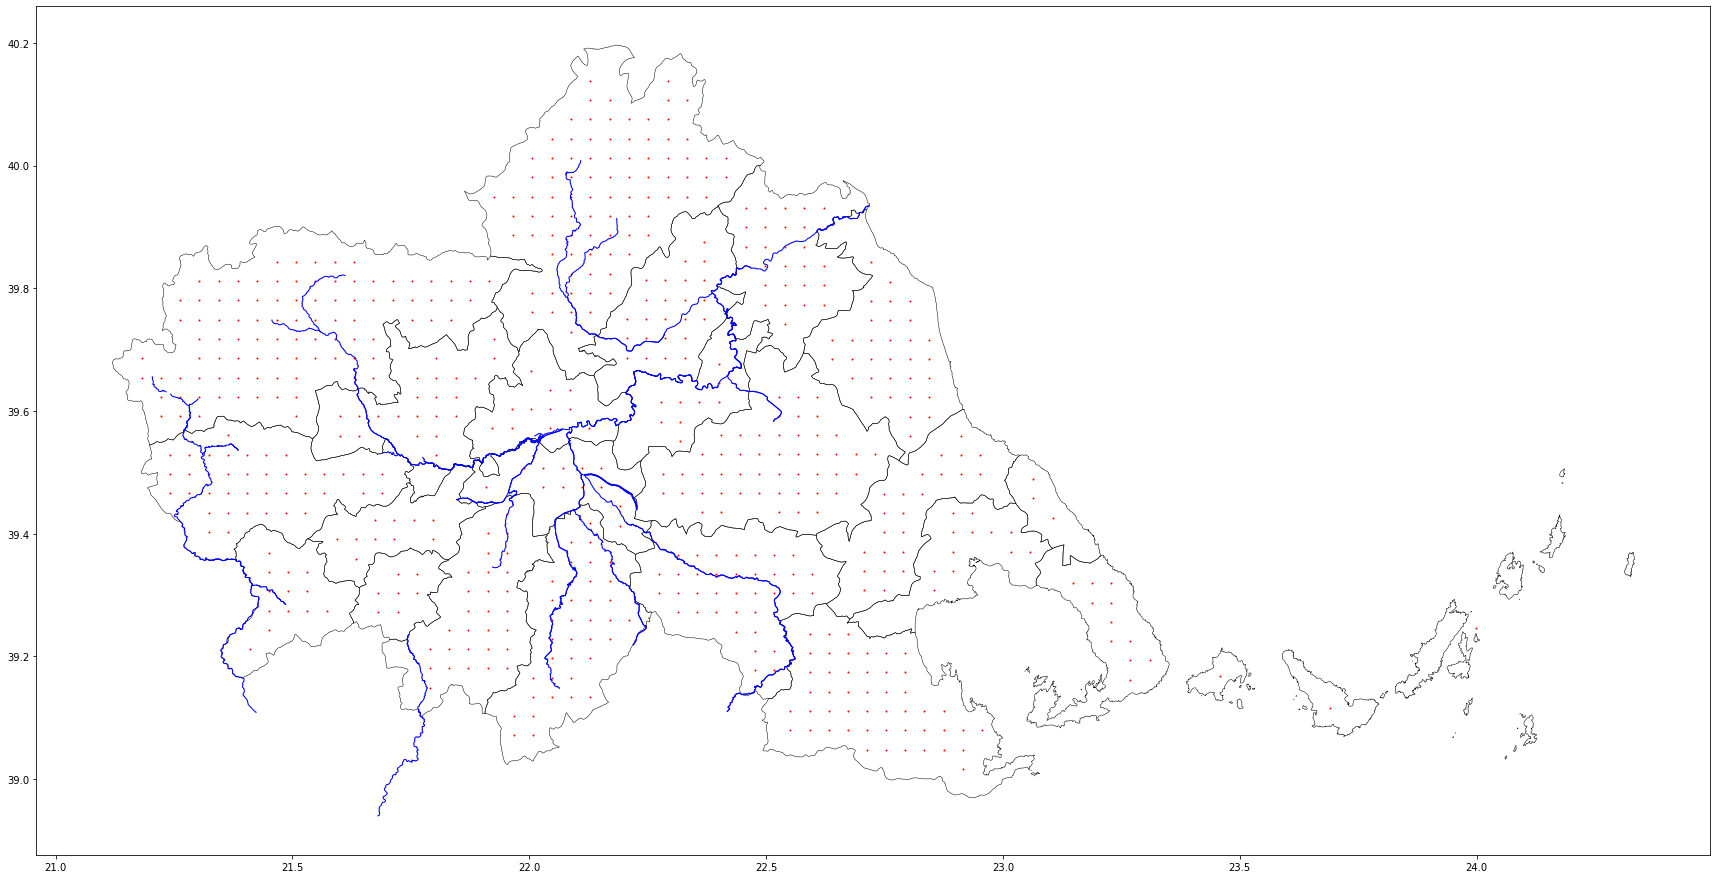

In [88]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [89]:
value_counts = nuts2_grid['lau1'].value_counts().sort_values()

In [90]:
arr = value_counts.values

In [91]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [92]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [93]:
value_counts_target

σκιαθου               1
σκοπελου              1
αλοννησου             1
ζαγορας μουρεσιου     1
λιμνης πλαστηρα       2
λαρισαιων             2
μουζακιου             2
νοτιου πηλιου         2
φαρκαδονας            2
βολου                 2
αργιθεας              3
παλαμα                3
τρικκαιων             4
ρηγα φερραιου         4
τυρναβου              4
τεμπων                5
καρδιτσας             5
αγιας                 6
φαρσαλων              6
σοφαδων               6
πυλης                 7
αλμυρου               8
κιλελερ               8
ελασσονας            15
καλαμπακας           16
dtype: int32

In [94]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: ζαγορας μουρεσιου || Value: 3 || Target Value: 1
Index: λιμνης πλαστηρα || Value: 7 || Target Value: 2
Index: λαρισαιων || Value: 9 || Target Value: 2
Index: μουζακιου || Value: 10 || Target Value: 2
Index: νοτιου πηλιου || Value: 11 || Target Value: 2
Index: φαρκαδονας || Value: 11 || Target Value: 2
Index: βολου || Value: 12 || Target Value: 2
Index: αργιθεας || Value: 13 || Target Value: 3
Index: παλαμα || Value: 13 || Target Value: 3
Index: τρικκαιων || Value: 22 || Target Value: 4
Index: ρηγα φερραιου || Value: 23 || Target Value: 4
Index: τυρναβου || Value: 24 || Target Value: 4
Index: τεμπων || Value: 26 || Target Value: 5
Index: καρδιτσας || Value: 29 || Target Value: 5
Index: αγιας || Value: 32 || Target Value: 6
Index: φαρσαλων || Value: 36 || Target Value: 6
Index: σοφαδων || Value: 37 || Target Value: 6
Index: πυλης || Value: 39 || Target Value: 7
Index: αλμυρου || Value: 48 || Target Value: 8
Index: κιλελερ || Value: 49 || Target Value: 8
Index: ελασσονας || Value: 

In [95]:
to_remove = pd.Series(data=points, index=idx)

In [96]:
to_remove

ζαγορας μουρεσιου     2
λιμνης πλαστηρα       5
λαρισαιων             7
μουζακιου             8
νοτιου πηλιου         9
φαρκαδονας            9
βολου                10
αργιθεας             10
παλαμα               10
τρικκαιων            18
ρηγα φερραιου        19
τυρναβου             20
τεμπων               21
καρδιτσας            24
αγιας                26
φαρσαλων             30
σοφαδων              31
πυλης                32
αλμυρου              40
κιλελερ              41
ελασσονας            73
καλαμπακας           78
dtype: int64

In [97]:
## removes some points

# indicies_to_remove = []

# for municipality, points in to_remove.iteritems():
#     indicies = nuts2_grid.loc[nuts2_grid['lau1'] ==  municipality].index.tolist()
#     to_removed = random.sample(indicies, points)
#     for item in to_removed:
#         indicies_to_remove.append(item)

# nuts2_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
# nuts2_grid.reset_index(inplace = True, drop = True)

In [98]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

<AxesSubplot:>

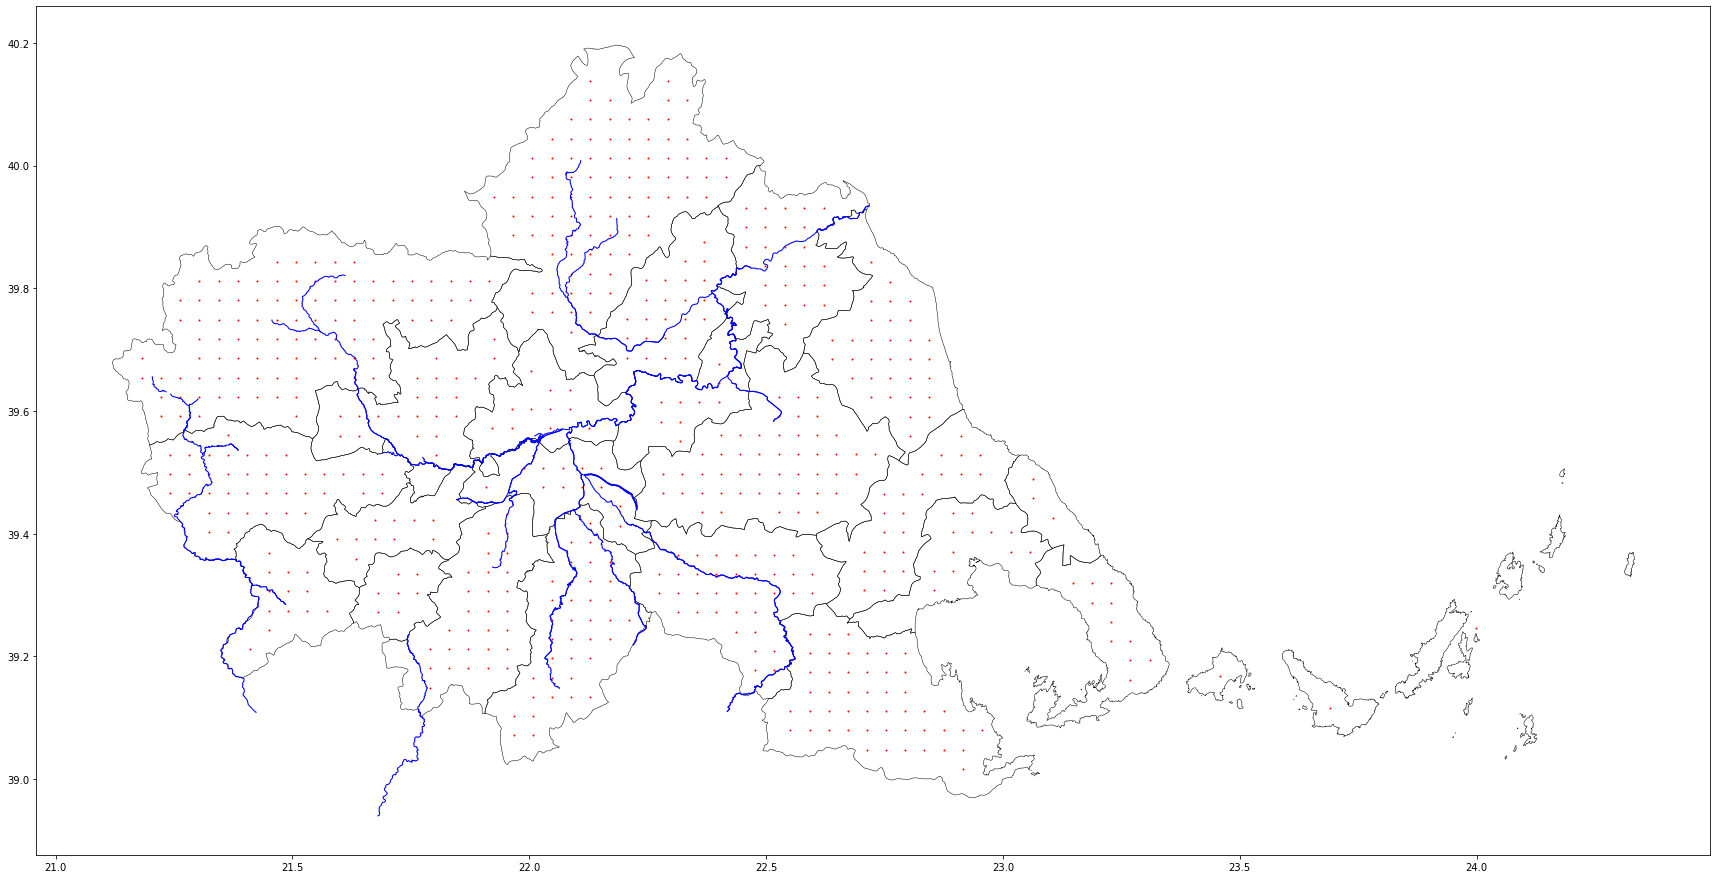

In [99]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [100]:
len(nuts2_grid['lau1'].unique())

25

In [101]:
nuts2_grid

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((22.66044 39.66926, 22.66044 39.70070...",αγιας,22.64007,39.68498,θεσσαλιας,POINT (22.64007 39.68498)
1,"POLYGON ((22.66044 39.70070, 22.66044 39.73215...",αγιας,22.64007,39.71642,θεσσαλιας,POINT (22.64007 39.71642)
2,"POLYGON ((22.70120 39.63782, 22.70120 39.66926...",αγιας,22.68082,39.65354,θεσσαλιας,POINT (22.68082 39.65354)
3,"POLYGON ((22.70120 39.66926, 22.70120 39.70070...",αγιας,22.68082,39.68498,θεσσαλιας,POINT (22.68082 39.68498)
4,"POLYGON ((22.70120 39.70070, 22.70120 39.73215...",αγιας,22.68082,39.71642,θεσσαλιας,POINT (22.68082 39.71642)
...,...,...,...,...,...,...
634,"POLYGON ((22.57757 39.35044, 22.57757 39.38188...",φαρσαλων,22.55731,39.36616,θεσσαλιας,POINT (22.55731 39.36616)
635,"POLYGON ((22.61811 39.28756, 22.61811 39.31900...",φαρσαλων,22.59784,39.30328,θεσσαλιας,POINT (22.59784 39.30328)
636,"POLYGON ((22.61811 39.31900, 22.61811 39.35044...",φαρσαλων,22.59784,39.33472,θεσσαλιας,POINT (22.59784 39.33472)
637,"MULTIPOLYGON (((24.14310 39.34155, 24.14307 39...",αλοννησου,23.99842,39.24585,θεσσαλιας,POINT (23.99842 39.24585)


In [102]:
final_grid = nuts2_grid[['nuts2', 'lau1', 'x', 'y']].sort_values(by=['lau1'])

In [103]:
final_grid

,nuts2,lau1,x,y
0,θεσσαλιας,αγιας,22.64007,39.68498
31,θεσσαλιας,αγιας,22.84384,39.71642
30,θεσσαλιας,αγιας,22.84384,39.68498
29,θεσσαλιας,αγιας,22.84384,39.65354
28,θεσσαλιας,αγιας,22.84384,39.62210
...,...,...,...,...
614,θεσσαλιας,φαρσαλων,22.39518,39.36616
615,θεσσαλιας,φαρσαλων,22.43571,39.24039
616,θεσσαλιας,φαρσαλων,22.43571,39.27184
619,θεσσαλιας,φαρσαλων,22.43571,39.36616


In [104]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid.csv', encoding=enc, index = False)